# Geodesic PCA on SPD matrices with same orientation

The Bures Wasserstein distance between two SPD matrices with same orientation (i.e., diagonalizable in the same orthonormal basis) is the Euclidean distance between the vectors of their eigenvalues square roots. In this notebook, we check that GPCA on a set of SPD matrices that are diagonalizable in the same basis is equivalent to Euclidean PCA on their eigenvalues square roots. 

Each $2\times 2$ SPD matrix can be represented as a point inside the half-cone $\mathcal C$ of SPD matrices, or by the image of the unit circle by the linear transformation of the plane induced by the matrix, i.e., an ellipse. Here we generate diagonal SPD matrices $\Sigma_{ij}$ with varying eigenvalues $1\leq a_i^2\leq 3$, $1\leq b_j^2\leq 2$. The matrices form a planar grid inside the cone $\mathcal C$,  and correspond to ellipses of varying width and height. 

Both GPCA and TPCA yield exactly the same results as Euclidean PCA on the eigenvalue square roots, as expected. The first component (red) captures the variation in $a$, while the second component (blue) captures the variation in $b$.

The figures shown in this notebook correspond to Figure 3 in [1].

[1] N. Vesseron, E. Cazelles, A. Le Brigant and T. Klein. On the Wasserstein Geodesic Principal Components Analysis of probability measures, *International Conference on Learning Representations (ICLR)*, 2026

In [1]:
import os
import sys
from pathlib import Path
sys.path.append(str(Path(os.getcwd()).parent.absolute()))

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

from pca.bures_wasserstein_geodesic_pca import *
from pca.bures_wasserstein_tangent_pca import *
from tools.plot_2d import *

INFO: Using numpy backend


#### Generate SPD matrices with same orientation and varying eigenvalues

In [3]:
dim = 2
n = 5

e1 = np.linspace(1., np.sqrt(3), n)
e2 = np.linspace(1., np.sqrt(2), n)
ee = np.meshgrid(e1, e2)
eig_sq_roots = np.stack(ee).T.reshape((n ** 2, dim))
points_spd = np.stack([np.diag(eig_sq_roots[i] ** 2) for i in range(n**2)])

#### Perform GPCA and visualize the projections on the first two components

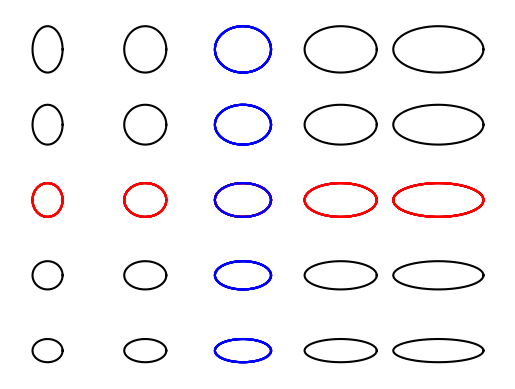

In [4]:
gpca = BuresWassersteinGPCA(dim=2).fit(points_spd)

plot_pca_results_with_ellipses_on_grid(points_spd, gpca, n=5)

#### Perform GPCA and visualize the projections on the first two components

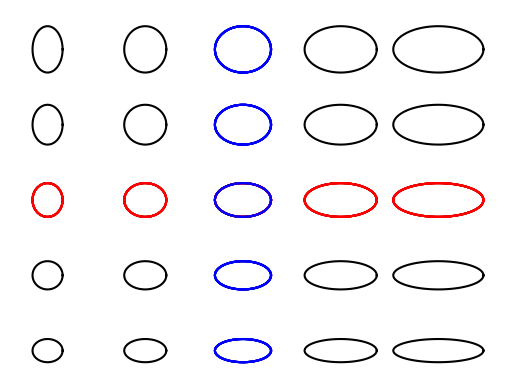

In [5]:
tpca = BuresWassersteinTPCA().fit(points_spd)

plot_pca_results_with_ellipses_on_grid(points_spd, tpca, n=5)

#### Visualize the results in the cone of SPD matrices

/Users/alebrigant/PycharmProjects/bures_wasserstein_pga/tools/plot_2d.py:98: RuntimeWarning: divide by zero encountered in scalar divide
  angle = np.arctan(- eigenvec[0, 1] / eigenvec[1, 1])


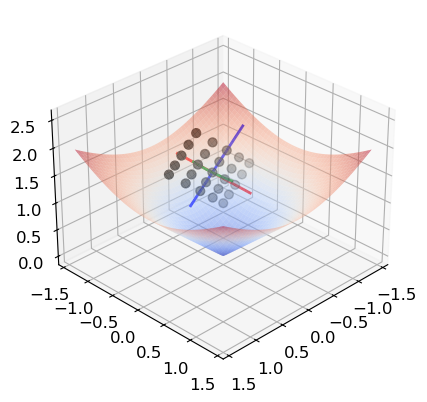

In [6]:
font = {'size': 12}
matplotlib.rc('font', **font)

plot_pca_results_in_cone(points_spd, gpca, bound=1.4)